---
title: "Token Economics of Prompt Delivery"
type: guide
authors:
  - name: Vadim Rudakov
    email: rudakow.wadim@gmail.com
description: BPE tokenizer mechanics and measured token costs across formats and tokenizers — the empirical companion to Format as Architecture.
tags: [prompts, architecture]
date: 2026-03-29
options:
  version: 0.1.0
  birth: 2026-03-29
---

This article provides the empirical foundation for the format decisions described in [Format as Architecture: Signal-to-Noise in Prompt Delivery](/ai_system/3_prompts/format_as_architecture_signal_noise_in_prompt_delivery.ipynb). We explain how BPE tokenizers work, measure token costs of four prompt formats on a production prompt, then validate the ranking across multiple tokenizers and languages.

## 1. BPE Tokenizer Mechanics

The token differences between formats are not arbitrary -- they follow directly from how Byte Pair Encoding (BPE) tokenizers work.

### 1.1 Space+Word Merging

In tokenizers trained on English text (cl100k_base, o200k_base), a space followed by a common word is typically stored as a single token in the vocabulary. The sequence ` hello` (space-prefixed) is one token, while `hello` without a leading space is a different token. This pattern appears because space-prefixed words occur billions of times in the training corpus.

This is why YAML's `key: value` structure is efficient -- the space after the colon merges with the following word. For example, in `rule: Give`, the tokenizer produces roughly `rule`, `:`, ` Give` -- three tokens. The equivalent JSON `"rule": "Give"` produces `"rule"`, `":`, ` "`, `Give`, `"` -- five tokens for the same content. These counts are illustrative; exact tokenization is BPE-context-dependent and can be verified with `enc.encode(text)` from `tiktoken`.

### 1.2 Indentation Cost

BPE tokenizers compress runs of spaces, but not infinitely. For example, with cl100k_base:

- 2 spaces → 1 token
- 4 spaces → 1 token
- 8 spaces → typically 2 tokens
- 16 spaces → typically 3-4 tokens

Deep nesting (common in YAML `|` blocks) accumulates an "indentation tax" -- each line pays for its leading whitespace. In a YAML literal block with 4-space base indentation, every content line carries 6-8 spaces (base + block indent), costing 2 tokens of pure whitespace per line. Over a 50-line block, that is ~100 tokens spent on indentation alone. This is why YAML literal style is more expensive than standard YAML, which keeps values on the same line as keys and avoids the block indentation entirely.

### 1.3 Punctuation Merging

Tokenizers trained on code (which is most modern tokenizers) have merged common punctuation sequences into single tokens. For example, with cl100k_base:

- `{"` → 1 token (merged pair, common in JSON/JS)
- `":` → 1 token (merged pair, JSON key-value separator)
- `"}` → 1 token (merged pair, JSON closing)
- `{` + `"` separately → 2 tokens

This is why minified JSON is so efficient -- sequences like `{"rule":` that look like 5+ characters are actually 2-3 tokens because the structural characters are already in the tokenizer's vocabulary as merged pairs. Pretty-printed JSON breaks these merges by inserting newlines and spaces between the punctuation.

### 1.4 Why You Cannot Remove All Whitespace

BPE tokenizers are trained on text with spaces between words. The standard tokenization of `The cat is fast` produces familiar tokens: `The`, ` cat`, ` is`, ` fast` -- each space-prefixed word is a single token the model has seen millions of times during training.

Removing inter-word spaces produces `Thecatisfast`, which the tokenizer splits into entirely different sub-word fragments -- something like `The`, `cat`, `is`, `fast` (without space prefixes) or worse, `Thec`, `at`, `isf`, `ast`. These are valid tokens, but they are *different tokens* from the space-prefixed versions the model learned to associate with meanings. The model's attention patterns were trained on ` cat` (space-prefixed), not `cat` (bare) -- these are literally different entries in the vocabulary with different learned associations.

The result is a **distributional shift**: the model can still decode the sequence, but the input token distribution has shifted away from what it was trained on. The learned attention patterns, positional associations, and semantic representations were all built on the space-prefixed token distribution. This degrades output quality -- not because information is lost, but because the model must handle unfamiliar token sequences, reducing the reliability of its learned associations ([A-26016](/architecture/evidence/analyses/A-26016_causal_masking_attention_mechanics_for_prompt_engineering.md)).

Structural whitespace (indentation, newlines) can be removed because the content tokens remain unchanged; semantic whitespace (between words) cannot because it changes the tokenization of the content itself.

### 1.5 Vocabulary Size Matters

Different tokenizers have vastly different vocabulary sizes. The following cell queries the actual vocabulary sizes from the tokenizer libraries:

In [1]:
from huggingface_hub import login; login()

In [2]:
import pandas as pd
import tiktoken
from transformers import AutoTokenizer

# HuggingFace tokenizer registry — single source of truth.
# Used in this cell (vocabulary sizes) and in Section 3.1 (format comparison).
HF_MODELS = [
    ('GPT-2',    'openai-community/gpt2'),
    ('Llama 3',  'meta-llama/Llama-3.2-1B'),
    ('GigaChat', 'ai-sage/GigaChat3.1-10B-A1.8B'),
    ('Qwen3',    'Qwen/Qwen3-Embedding-0.6B'),
    ('Gemma 2',  'google/gemma-2-2b'),
]

rows = []
for label, enc_name, used_by in [
    ('cl100k_base', 'cl100k_base', 'GPT-4'),
    ('o200k_base',  'o200k_base',  'GPT-4o'),
]:
    enc = tiktoken.get_encoding(enc_name)
    rows.append({'Tokenizer': label, 'Vocabulary size': enc.n_vocab, 'Used by': used_by})

for label, mid in HF_MODELS:
    try:
        tok = AutoTokenizer.from_pretrained(mid, trust_remote_code=True)
    except OSError as e:
        rows.append({'Tokenizer': label, 'Vocabulary size': None, 'Used by': f'ERROR: {e}'})
        continue
    rows.append({'Tokenizer': label, 'Vocabulary size': tok.vocab_size, 'Used by': mid.split('/')[-1]})

df_vocab = pd.DataFrame(rows).set_index('Tokenizer')
display(df_vocab.style.format({'Vocabulary size': lambda v: 'ERROR' if pd.isna(v) else f'{int(v):,}'}))

,Vocabulary size,Used by
Tokenizer,,
cl100k_base,"100,277",GPT-4
o200k_base,"200,019",GPT-4o
GPT-2,"50,257",gpt2
Llama 3,"128,000",Llama-3.2-1B
GigaChat,"128,000",GigaChat3.1-10B-A1.8B
Qwen3,"151,643",Qwen3-Embedding-0.6B
Gemma 2,"256,000",gemma-2-2b


Within the same model family, a larger vocabulary generally reduces token counts — more character sequences are stored as single merged tokens. Across different model families this does not hold: vocabulary architecture and training data distribution dominate over raw vocabulary size. The data in {ref}`te-measuring` and {ref}`te-cross-tokenizer` confirms this:

- `o200k_base` (GPT-4o, 200k vocab) produces *more* tokens than `cl100k_base` (GPT-4, 100k vocab) for Minified JSON on the same prompt.
- In the [Appendix](/ai_system/3_prompts/appendix_yaml_serializer_variance.ipynb), Gemma 2 (256k) produces more tokens than both Qwen3 (151k) and Llama 3 (128k) despite having the largest vocabulary.

:::{note}
**Model family** here means tokenizers that share the same BPE training approach and corpus, differing only in vocabulary size (e.g., successive versions of the same design). GPT-4 (`cl100k_base`) and GPT-4o (`o200k_base`) were trained on different corpora with a redesigned merge table — they are different families despite both being OpenAI models. Qwen3, Llama 3, and Gemma 2 are independent families. Comparing token counts across families tells you about training data differences, not vocabulary efficiency.
:::

The *relative ranking between formats* (Minified JSON cheapest, Standard YAML second) holds consistently across all tested tokenizers regardless of family. Use that ranking for format decisions; do not use vocabulary size to predict absolute token counts across model families.

(te-measuring)=
## 2. Measuring Token Cost by Format

We measure token costs on an actual production prompt ([devops_consultant.json](/ai_system/3_prompts/consultants/devops_consultant.json)) so you can verify the claims and reproduce them on your own prompts.

We use OpenAI's `tiktoken` library because it implements the exact BPE tokenizers used by GPT-4 (`cl100k_base`) and GPT-4o (`o200k_base`).

### 2.1 Setup

In [3]:
import json
from pathlib import Path

import pandas as pd
import tiktoken
import yaml


def json_to_yaml(data: dict) -> str:
    """Convert a dict to standard YAML string.

    Uses PyYAML default width=80 (line-wrapping enabled). This adds ~4% token
    overhead vs width=∞ on prompts with long strings. See the Appendix for
    isolation measurements of the wrapping effect.
    """
    return yaml.dump(data, allow_unicode=True, default_flow_style=False, sort_keys=False)


def json_to_yaml_literal(data: dict) -> str:
    """Convert a dict to YAML with literal block scalars for multiline strings."""

    class LiteralStr(str):
        pass

    class LiteralDumper(yaml.Dumper):
        pass

    LiteralDumper.add_representer(
        LiteralStr,
        lambda dumper, val: dumper.represent_scalar('tag:yaml.org,2002:str', val, style='|'),
    )

    def apply_literal_style(obj):
        if isinstance(obj, str) and '\n' in obj:
            return LiteralStr(obj)
        if isinstance(obj, str):
            return LiteralStr(obj + '\n')
        if isinstance(obj, dict):
            return {k: apply_literal_style(v) for k, v in obj.items()}
        if isinstance(obj, list):
            return [apply_literal_style(i) for i in obj]
        return obj

    return yaml.dump(apply_literal_style(data), Dumper=LiteralDumper,
                     allow_unicode=True, default_flow_style=False, sort_keys=False)


# Load the production prompt
PROMPT_FILE = Path('consultants/devops_consultant.json')
prompt_data = json.loads(PROMPT_FILE.read_text())

print(f"Prompt file: {PROMPT_FILE}")
print(f"File size: {PROMPT_FILE.stat().st_size} bytes")
print(f"Top-level keys: {list(prompt_data.keys())[:5]}...")

Prompt file: consultants/devops_consultant.json
File size: 12199 bytes
Top-level keys: ['metadata', 'input_protocol', 'consultant_persona', 'target', 'consulting_protocol']...


### 2.2 Token Count by Format

In [4]:
enc = tiktoken.get_encoding('cl100k_base')

# Prepare all four format variants from the same data
formats = {
    'Minified JSON': json.dumps(prompt_data, ensure_ascii=False, separators=(',', ':')),
    'Standard YAML (PyYAML, w=80)': json_to_yaml(prompt_data),
    'Pretty JSON': json.dumps(prompt_data, ensure_ascii=False, indent=2),
    'YAML Literal (PyYAML)': json_to_yaml_literal(prompt_data),
}

rows = []
for name, text in formats.items():
    n = len(enc.encode(text))
    rows.append({'Format': name, 'Tokens': n, 'Chars': len(text)})

df_fmt = pd.DataFrame(rows).sort_values('Tokens').reset_index(drop=True)
baseline = df_fmt['Tokens'].iloc[0]
df_fmt['Delta'] = df_fmt.apply(
    lambda r: 'baseline' if r['Tokens'] == baseline
    else f"+{int(r['Tokens'] - baseline)} (+{(r['Tokens'] - baseline) / baseline * 100:.1f}%)",
    axis=1,
)
df_fmt['chars/token'] = (df_fmt['Chars'] / df_fmt['Tokens']).round(2)
df_fmt = df_fmt[['Format', 'Tokens', 'Delta', 'chars/token']].set_index('Format')

display(df_fmt.style
    .highlight_min(subset=['Tokens'], color='#c6efce')
    .highlight_max(subset=['Tokens'], color='#ffc7ce'))

,Tokens,Delta,chars/token
Format,,,
Minified JSON,2407,baseline,4.390000
"Standard YAML (PyYAML, w=80)",2689,+282 (+11.7%),4.210000
YAML Literal (PyYAML),2788,+381 (+15.8%),4.250000
Pretty JSON,2848,+441 (+18.3%),4.250000


The `chars/token` column shows how many source characters each token encodes on average — higher values mean more efficient compression. See {ref}`te-chars-per-token` for a detailed explanation.

### 2.3 Comparison with `o200k_base` (GPT-4o tokenizer)

The `o200k_base` tokenizer has a larger vocabulary (200k vs 100k tokens), which means it can represent more character sequences as single tokens. Let's see how this affects the ranking.

In [5]:
encodings = {
    'cl100k_base (GPT-4)':  tiktoken.get_encoding('cl100k_base'),
    'o200k_base (GPT-4o)':  tiktoken.get_encoding('o200k_base'),
}

tok_cols = list(encodings.keys())
rows = []
for name, text in formats.items():
    counts = {label: len(enc.encode(text)) for label, enc in encodings.items()}
    counts['Difference'] = counts[tok_cols[1]] - counts[tok_cols[0]]
    counts['Format'] = name
    rows.append(counts)

df_enc = pd.DataFrame(rows).set_index('Format')
display(df_enc.style
    .highlight_min(subset=tok_cols, axis=0, color='#c6efce')
    .highlight_max(subset=tok_cols, axis=0, color='#ffc7ce')
    .format({'Difference': '{:+d}'}))

,cl100k_base (GPT-4),o200k_base (GPT-4o),Difference
Format,,,
Minified JSON,2407,2416,+9
"Standard YAML (PyYAML, w=80)",2689,2686,-3
Pretty JSON,2848,2843,-5
YAML Literal (PyYAML),2788,2784,-4


### 2.4 Visualization

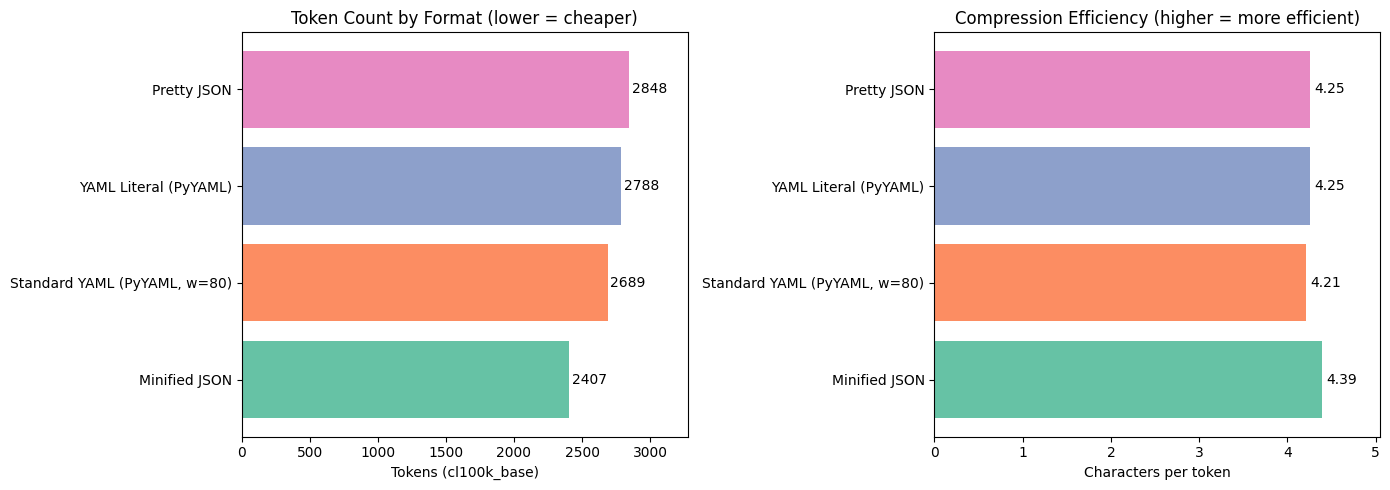

In [6]:
import matplotlib.pyplot as plt
import numpy as np

enc = tiktoken.get_encoding('cl100k_base')

names = list(formats.keys())
counts = [len(enc.encode(text)) for text in formats.values()]
cpt = [round(len(text) / len(enc.encode(text)), 2) for text in formats.values()]

# Sort by token count
order = np.argsort(counts)
names = [names[i] for i in order]
counts = [counts[i] for i in order]
cpt = [cpt[i] for i in order]

colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Token count bar chart
bars = ax1.barh(names, counts, color=colors)
ax1.set_xlabel('Tokens (cl100k_base)')
ax1.set_title('Token Count by Format (lower = cheaper)')
for bar, count in zip(bars, counts):
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=10)
ax1.set_xlim(0, max(counts) * 1.15)

# Chars/token bar chart
bars2 = ax2.barh(names, cpt, color=colors)
ax2.set_xlabel('Characters per token')
ax2.set_title('Compression Efficiency (higher = more efficient)')
for bar, val in zip(bars2, cpt):
    ax2.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)
ax2.set_xlim(0, max(cpt) * 1.15)

plt.tight_layout()
plt.show()

### 2.5 Results Analysis

Run the cells above to see the exact numbers for the current version of the prompt file. The pattern that consistently emerges:

1. **Minified JSON has the lowest absolute token count** -- roughly 20% cheaper than the most expensive format. If you are strictly budget-constrained or hitting a context window limit, `jq -c` is the answer.

2. **Standard YAML beats Pretty JSON** -- typically by ~7-12%, depending on the serializer and its `width` setting. PyYAML defaults to `width=80` (line-wrapping), which adds ~4% overhead from continuation-line tokens; setting `width=float('inf')` eliminates this and widens the gap further. The colons-and-indentation structure is genuinely more token-efficient than braces-and-quotes. This contradicts the naive assumption that "less punctuation = fewer tokens"; what matters is how well the format aligns with BPE merge patterns.

3. **YAML literal (`|`) is expensive — but the ranking depends on the serializer.** With PyYAML, YAML literal is cheaper than Pretty JSON on all tested files. With yq, YAML literal flips to more expensive than Pretty JSON on 4 out of 5 files, because yq applies `|-` (strip) to all scalars including booleans, inflating the count. The indentation tax on every line inside a `|` block is the dominant cost. See the [Appendix: YAML Serializer Variance](/ai_system/3_prompts/appendix_yaml_serializer_variance.ipynb) for the full isolation and per-file ranking analysis.

4. **Token efficiency ≠ reasoning quality.** Minified JSON saves tokens but eliminates the structural signposts (newlines, indentation) that help the transformer maintain positional awareness during the prefill phase -- when all prompt tokens are processed in parallel and each token's share of the attention probability mass is determined by softmax normalization over Query-Key dot products. These "attention anchors" are an empirical observation about models trained on structured text, not an architectural guarantee ([A-26016](/architecture/evidence/analyses/A-26016_causal_masking_attention_mechanics_for_prompt_engineering.md)). Standard YAML costs slightly more than minified JSON but provides these boundary signals. For most production use cases, the modest token premium is worth the reasoning quality gain.

(te-cross-tokenizer)=
## 3. Cross-Tokenizer Validation

The measurements above use OpenAI's tokenizers. Do the rankings hold for tokenizers used by local models? We test with HuggingFace `AutoTokenizer` on five additional tokenizers: GPT-2 (50k), Llama 3 (128k), GigaChat (Russian-optimized), Qwen3 (151k), and Gemma 2 (256k). Llama 3, GigaChat, and Gemma 2 are gated on HuggingFace and require login — unavailable tokenizers are skipped automatically. For serializer-variance measurements across the same tokenizer set, see the [Appendix: YAML Serializer Variance](/ai_system/3_prompts/appendix_yaml_serializer_variance.ipynb), Section D.

### 3.1 Multi-Tokenizer Format Comparison

In [7]:
# Load tokenizers from HF_MODELS registry (defined in Section 1.5).
# Labels are decorated with vocab size discovered at load time.
# Gated models require HF login; unavailable ones are skipped automatically.
hf_tokenizers = {}
for label, mid in HF_MODELS:
    try:
        tok = AutoTokenizer.from_pretrained(mid, trust_remote_code=True)
        vocab_k = round(tok.vocab_size / 1000)
        hf_tokenizers[f'{label} ({vocab_k}k)'] = tok
    except OSError as e:
        print(f'  {label} ({mid}): unavailable — {e}')

rows = []
for fmt_name, text in formats.items():
    row = {'Format': fmt_name}
    for label, tokenizer in hf_tokenizers.items():
        n = len(tokenizer.encode(text))
        row[(label, 'tokens')]      = n
        row[(label, 'chars/token')] = round(len(text) / n, 2)
    rows.append(row)

df_hf = pd.DataFrame(rows).set_index('Format')
df_hf.columns = pd.MultiIndex.from_tuples(df_hf.columns)

token_cols = [(label, 'tokens') for label in hf_tokenizers]
display(df_hf.style
    .highlight_min(subset=token_cols, axis=0, color='#c6efce')
    .highlight_max(subset=token_cols, axis=0, color='#ffc7ce'))

Token indices sequence length is longer than the specified maximum sequence length for this model (2681 > 1024). Running this sequence through the model will result in indexing errors


### 3.2 Cross-Tokenizer Visualization

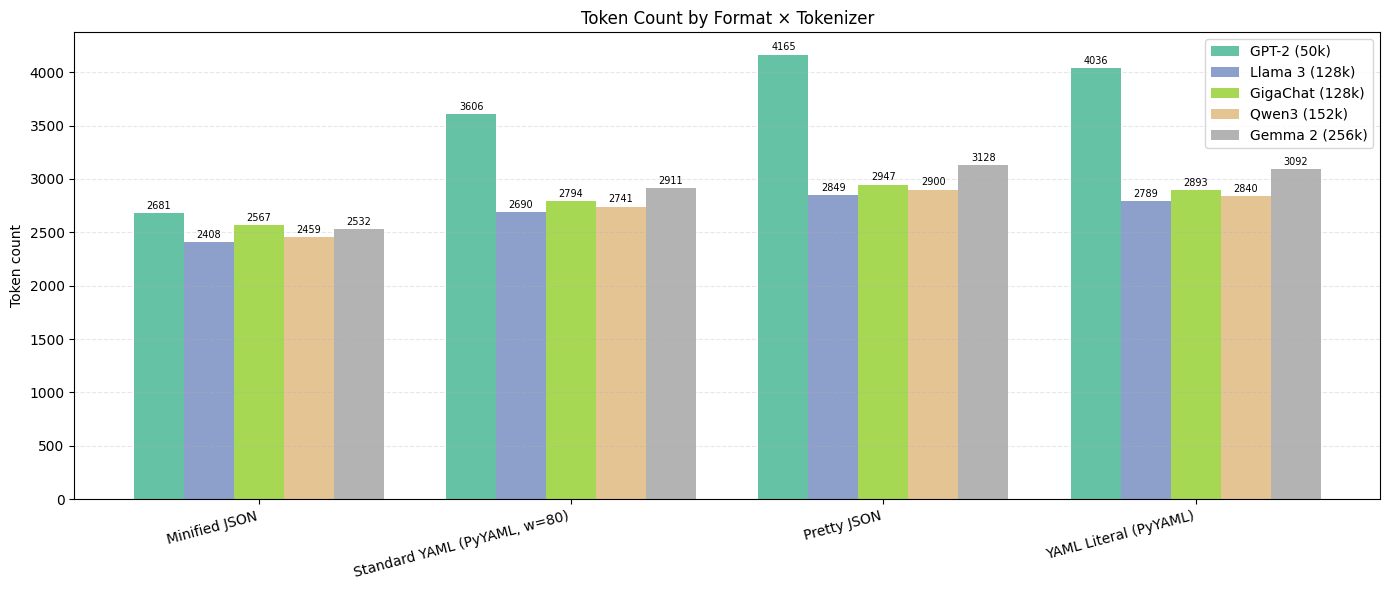

In [8]:
# Collect data
data = {}
for label, tokenizer in hf_tokenizers.items():
    data[label] = {fmt: len(tokenizer.encode(text)) for fmt, text in formats.items()}

fmt_names = list(formats.keys())
n_tokenizers = len(data)
x = np.arange(len(fmt_names))
bar_width = 0.8 / n_tokenizers  # distribute bars evenly regardless of tokenizer count

colors = plt.colormaps['Set2'].resampled(n_tokenizers).colors

fig, ax = plt.subplots(figsize=(14, 6))
for i, (label, counts) in enumerate(data.items()):
    values = [counts[fmt] for fmt in fmt_names]
    offset = (i - n_tokenizers / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, values, bar_width, label=label, color=colors[i])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', va='bottom', fontsize=7)

ax.set_ylabel('Token count')
ax.set_title('Token Count by Format × Tokenizer')
ax.set_xticks(x)
ax.set_xticklabels(fmt_names, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

(te-chars-per-token)=
### 3.3 The `chars/token` Efficiency Metric

The `chars/token` (characters per token) metric provides an intuitive measure of tokenizer efficiency: higher values mean the tokenizer compresses text more aggressively. A tokenizer with 4.0 chars/token packs twice as much content per token as one with 2.0 chars/token.

This metric varies by:
- **Vocabulary size** -- larger vocabularies generally yield higher chars/token
- **Language** -- tokenizers trained primarily on English compress English text better than Cyrillic, CJK, or other scripts (see Section 4)
- **Content type** -- code and structured text may compress differently than prose

For format comparison, chars/token reveals whether a format's token savings come from compressing structure or from compressing content.

## 4. Language Effects

Tokenizer efficiency varies dramatically by language. GPT-2's vocabulary was built primarily from English text; Cyrillic characters are fragmented into byte-level tokens. Modern multilingual tokenizers (Qwen3, o200k_base) handle Russian far better. GigaChat's tokenizer was built specifically for Russian, making it the most relevant comparison point for Russian-language prompt engineering.

This matters for format choice: **format overhead as a percentage of total tokens changes by language.** When content tokens are already heavily fragmented (Russian on GPT-2), structural tokens are a smaller fraction of the total. When content tokens are efficiently compressed (English on Qwen3), structural overhead is proportionally larger and the format choice matters more.

### 4.1 Russian vs English Tokenization

,Russian,English,Ru/En ratio
Tokenizer,,,
GPT-2 (50k),122,17,7.18x
Llama 3 (128k),40,18,2.22x
GigaChat (128k),22,19,1.16x
Qwen3 (152k),43,18,2.39x
Gemma 2 (256k),32,17,1.88x


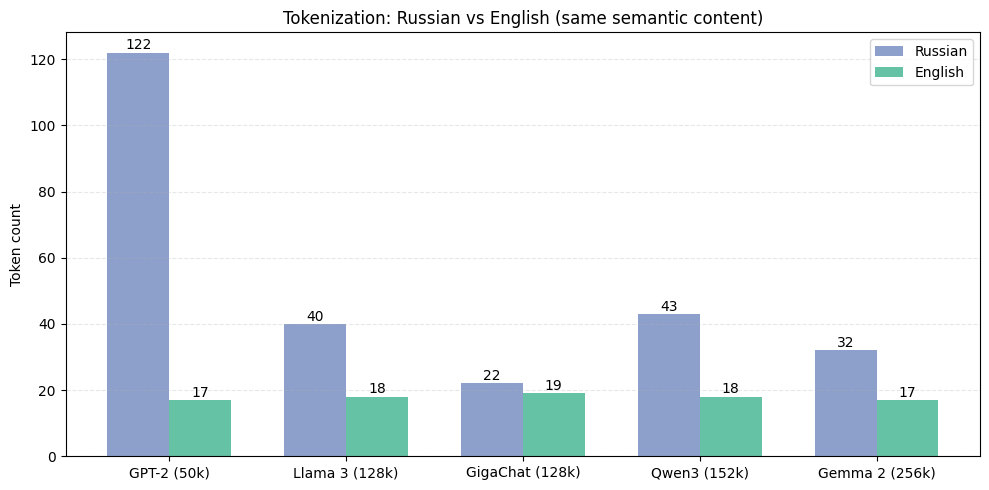

In [9]:
text_ru = 'Российская Федерация воздержалась при голосовании по резолюции Генеральной Ассамблеи ООН о ядерном разоружении'
text_en = 'The Russian Federation abstained from voting on the UN General Assembly resolution on nuclear disarmament'

rows_lang = []
for label, tokenizer in hf_tokenizers.items():
    n_ru = len(tokenizer.encode(text_ru))
    n_en = len(tokenizer.encode(text_en))
    rows_lang.append({
        'Tokenizer': label,
        'Russian':   n_ru,
        'English':   n_en,
        'Ru/En ratio': round(n_ru / n_en, 2),
    })

df_lang = pd.DataFrame(rows_lang).set_index('Tokenizer')
results_lang = {r['Tokenizer']: (r['Russian'], r['English']) for r in rows_lang}
display(df_lang.style
    .highlight_min(subset=['Russian', 'English'], axis=0, color='#c6efce')
    .highlight_max(subset=['Russian', 'English'], axis=0, color='#ffc7ce')
    .format({'Ru/En ratio': '{:.2f}x'}))

# Visualization
model_labels = list(results_lang.keys())
ru_counts = [results_lang[m][0] for m in model_labels]
en_counts = [results_lang[m][1] for m in model_labels]

x = np.arange(len(model_labels))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_ru = ax.bar(x - bar_width/2, ru_counts, bar_width, label='Russian', color='#8da0cb')
bars_en = ax.bar(x + bar_width/2, en_counts, bar_width, label='English', color='#66c2a5')

ax.set_ylabel('Token count')
ax.set_title('Tokenization: Russian vs English (same semantic content)')
ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.3)

for bar, val in zip(bars_ru, ru_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontsize=10)
for bar, val in zip(bars_en, en_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### 4.2 Implications for Format Choice

When working with Russian-language prompts on a small-vocabulary tokenizer (e.g., GPT-2 family), the content tokens dominate the total count so heavily that the format overhead shrinks relative to the content token count — switching from JSON to YAML saves a small absolute number of tokens against a large base.

When working with English-language prompts on a large-vocabulary tokenizer (e.g., Qwen3, o200k_base), content compresses efficiently and format overhead becomes a larger fraction of the total -- the savings from format choice translate to meaningful token reductions.

**Practical rule:** the format decision framework from [Format as Architecture](/ai_system/3_prompts/format_as_architecture_signal_noise_in_prompt_delivery.ipynb) applies most strongly when the tokenizer handles your language efficiently. If your tokenizer fragments your language heavily, focus on vocabulary selection (model choice) before format optimization.

## 5. Summary

Measurements on [devops_consultant.json](/ai_system/3_prompts/consultants/devops_consultant.json) (and 4 additional prompt files measured in the [Appendix: YAML Serializer Variance](/ai_system/3_prompts/appendix_yaml_serializer_variance.ipynb)) confirm the format ranking across tokenizers:

| Ranking | Format | Relative cost (PyYAML, cl100k_base) | Attention anchors | Best for |
|---------|--------|-------------------------------------|-------------------|----------|
| 1 | Minified JSON | Lowest (baseline) | None | Budget-constrained, context window limits |
| 2 | Standard YAML | +7% (`w=∞`) to +12% (`w=80`) | Strong (indentation) | Production instructions (best cost/quality) |
| 3 | YAML Literal (`\|`) | ~16% more (PyYAML) | Strong (indentation) | Whitespace-sensitive content only |
| 4 | Pretty JSON | ~18% more | Moderate (braces) | Development artifacts, human editing |

:::{note}
The ranking of positions 3 and 4 is **serializer-dependent**. With PyYAML, YAML Literal is cheaper than Pretty JSON. With yq, it flips — YAML Literal exceeds Pretty JSON on 4 out of 5 tested files due to yq's `|-` coercion of all scalars. The `width` parameter also shifts position 2: PyYAML's default `width=80` (line-wrapping) adds ~4% overhead that `width=float('inf')` eliminates. See the [Appendix: YAML Serializer Variance](/ai_system/3_prompts/appendix_yaml_serializer_variance.ipynb) for full isolation experiments and per-file rankings.
:::

The top-2 ranking (Minified JSON cheapest, Standard YAML second) holds across all tokenizers tested — from GPT-2 (50k vocab) to Gemma 2 (256k vocab). Vocabulary size affects absolute counts but not relative ordering.

Language effects add a second dimension: format optimization matters most when your tokenizer handles your language efficiently. For heavily-fragmented languages (Cyrillic on GPT-2), model/tokenizer selection has a larger impact than format choice.

The critical insight remains: **token efficiency ≠ reasoning quality.** The cheapest format (minified JSON) eliminates the structural signposts that help the transformer follow complex instructions during the prefill phase. Standard YAML is the optimal balance for production prompt delivery.